In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
   
import warnings
warnings.filterwarnings('ignore')

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

from xgboost import XGBRegressor

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_percentage_error

from datetime import datetime


In [2]:
# Load Dataset
df = pd.read_csv("P675 DATASET.csv")
df

,Date,Open,High,Low,Close,Adj Close,Volume
0,2012-01-03,58.485714,58.928570,58.428570,58.747143,50.765709,75555200
1,2012-01-04,58.571430,59.240002,58.468571,59.062859,51.038536,65005500
2,2012-01-05,59.278572,59.792858,58.952858,59.718571,51.605175,67817400
3,2012-01-06,59.967144,60.392857,59.888573,60.342857,52.144630,79573200
4,2012-01-09,60.785713,61.107143,60.192856,60.247143,52.061932,98506100
...,...,...,...,...,...,...,...
2006,2019-12-23,280.529999,284.250000,280.369995,284.000000,282.054138,24643000
2007,2019-12-24,284.690002,284.890015,282.920013,284.269989,282.322266,12119700
2008,2019-12-26,284.820007,289.980011,284.700012,289.910004,287.923645,23280300
2009,2019-12-27,291.119995,293.970001,288.119995,289.799988,287.814392,36566500


In [3]:
# Shape of Dataset
df.shape

(2011, 7)

In [4]:
print(df.index)
print(type(df.index))

RangeIndex(start=0, stop=2011, step=1)
<class 'pandas.core.indexes.range.RangeIndex'>


In [5]:
# Display Column Names
df.columns

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume'], dtype='object')

In [6]:
# Check Data Types
df.dtypes

Date          object
Open         float64
High         float64
Low          float64
Close        float64
Adj Close    float64
Volume         int64
dtype: object

In [7]:
# Dataset Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2011 entries, 0 to 2010
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       2011 non-null   object 
 1   Open       2011 non-null   float64
 2   High       2011 non-null   float64
 3   Low        2011 non-null   float64
 4   Close      2011 non-null   float64
 5   Adj Close  2011 non-null   float64
 6   Volume     2011 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 110.1+ KB


In [8]:
# Statistical Summary
df.describe()

,Open,High,Low,Close,Adj Close,Volume
count,2011.000000,2011.000000,2011.000000,2011.000000,2011.000000,2.011000e+03
mean,126.707469,127.827594,125.580258,126.741235,119.505548,5.949670e+07
std,50.483753,50.926301,50.124940,50.578369,52.438444,4.683856e+07
min,55.424286,57.085712,55.014286,55.790001,48.921928,1.136200e+07
25%,85.882858,86.717858,85.056427,86.202145,75.056679,2.758565e+07
50%,113.050003,114.190002,111.870003,113.050003,105.222908,4.346900e+07
75%,165.190002,167.409996,163.424995,165.245002,160.047111,7.471030e+07
max,291.119995,293.970001,288.119995,291.519989,289.522614,3.765300e+08


In [9]:
# Check Missing Values
df.isnull().sum()

Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

In [10]:
# Check Duplicate Rows
df.duplicated().sum()

np.int64(0)

In [11]:
# Convert Date Column into Datetime
df['Date'] = pd.to_datetime(df['Date'])

In [12]:
# Check Data Types Again
df.dtypes

Date         datetime64[ns]
Open                float64
High                float64
Low                 float64
Close               float64
Adj Close           float64
Volume                int64
dtype: object

In [13]:
# Sort Dataset by Date
df = df.sort_values(by='Date')

In [14]:
# Set Date Column as Index
df.set_index('Date', inplace=True)

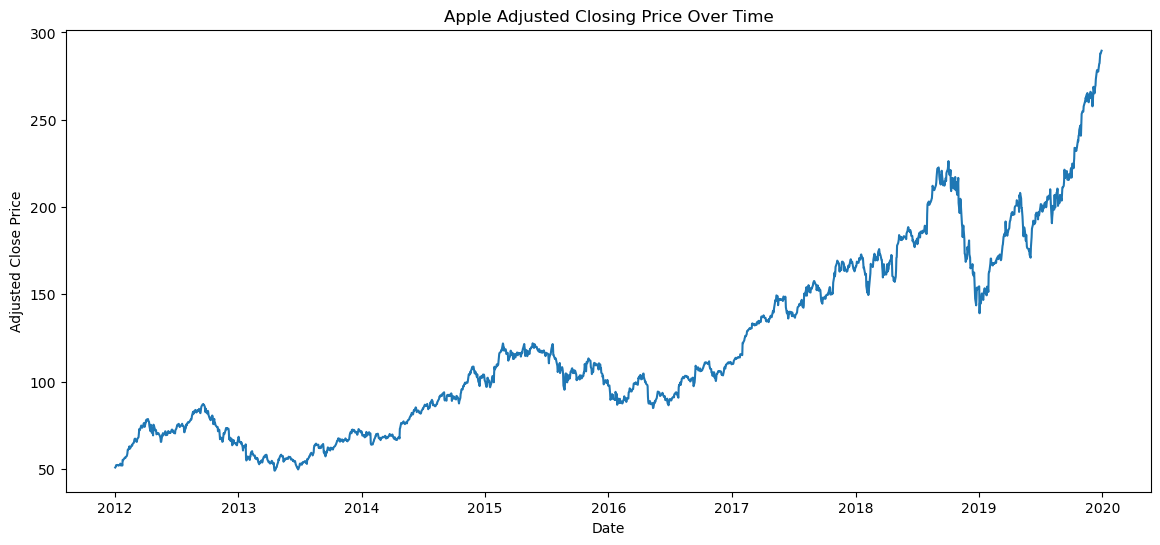

In [15]:
# Plot Adjusted Closing Price

plt.figure(figsize=(14,6))

plt.plot(df['Adj Close'])

plt.title('Apple Adjusted Closing Price Over Time')
plt.xlabel('Date')
plt.ylabel('Adjusted Close Price')

plt.show()

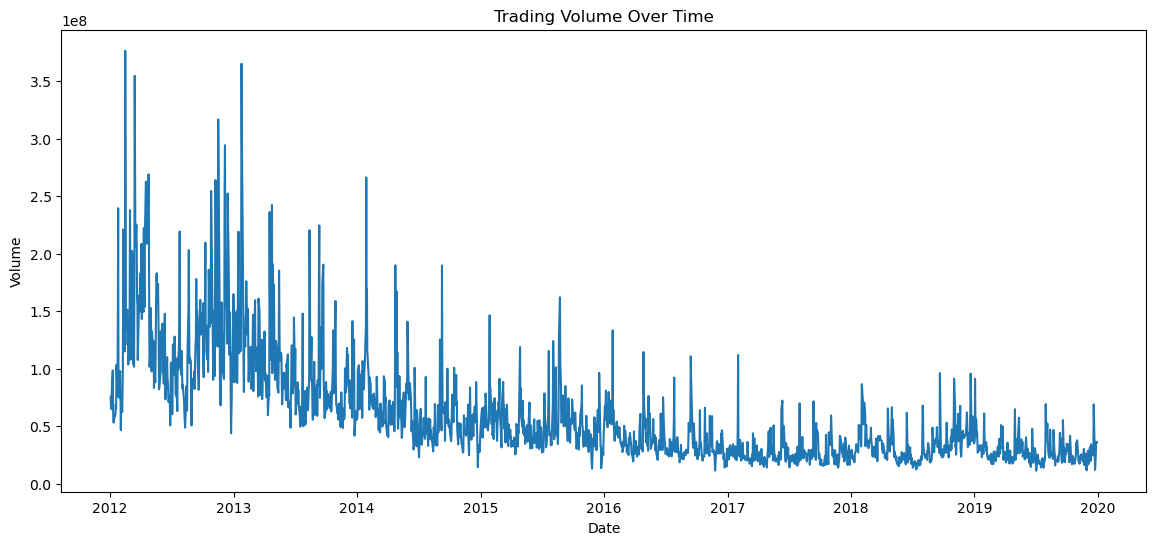

In [16]:
# Plot Trading Volume

plt.figure(figsize=(14,6))

plt.plot(df['Volume'])

plt.title('Trading Volume Over Time')
plt.xlabel('Date')
plt.ylabel('Volume')

plt.show()

In [17]:
# Create Moving Averages

df['MA10'] = df['Adj Close'].rolling(window=10).mean()

df['MA30'] = df['Adj Close'].rolling(window=30).mean()

df['MA_50'] = df['Adj Close'].rolling(window=50).mean()

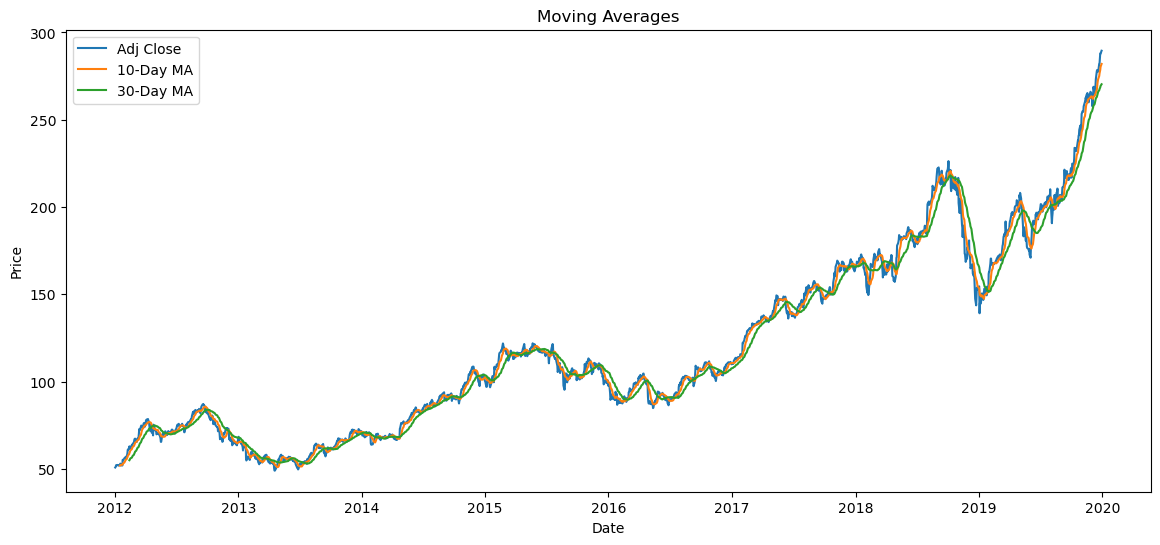

In [18]:
# Plot Moving Averages

plt.figure(figsize=(14,6))
plt.plot(df['Adj Close'], label='Adj Close')
plt.plot(df['MA10'], label='10-Day MA')
plt.plot(df['MA30'], label='30-Day MA')
plt.title('Moving Averages')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()

In [19]:
# Calculate Daily Returns

df['Daily Return'] = df['Adj Close'].pct_change()

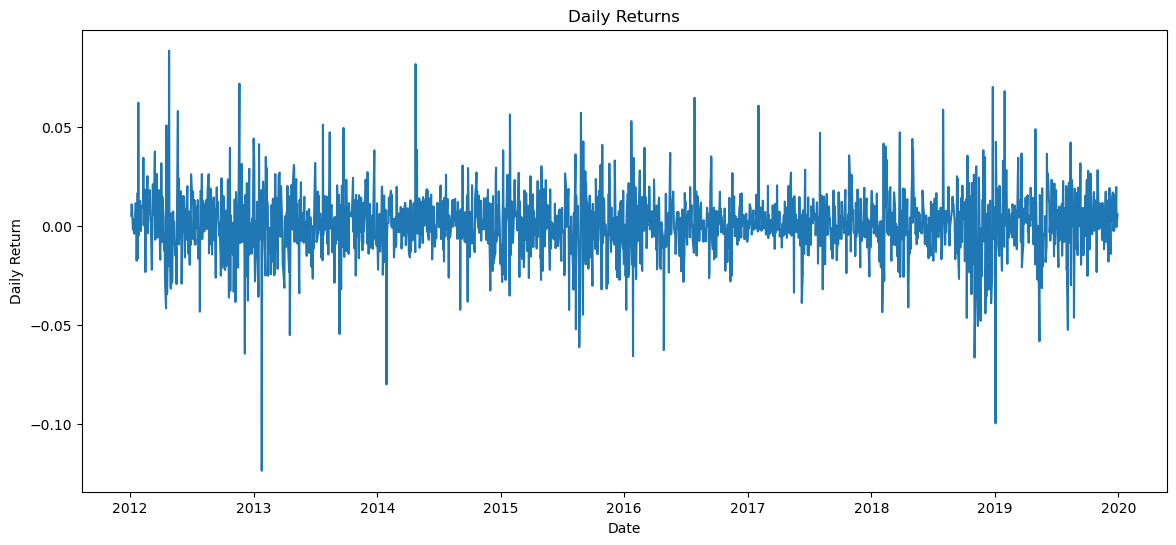

In [20]:
# Plot Daily Returns

plt.figure(figsize=(14,6))

plt.plot(df['Daily Return'])

plt.title('Daily Returns')

plt.xlabel('Date')
plt.ylabel('Daily Return')

plt.show()

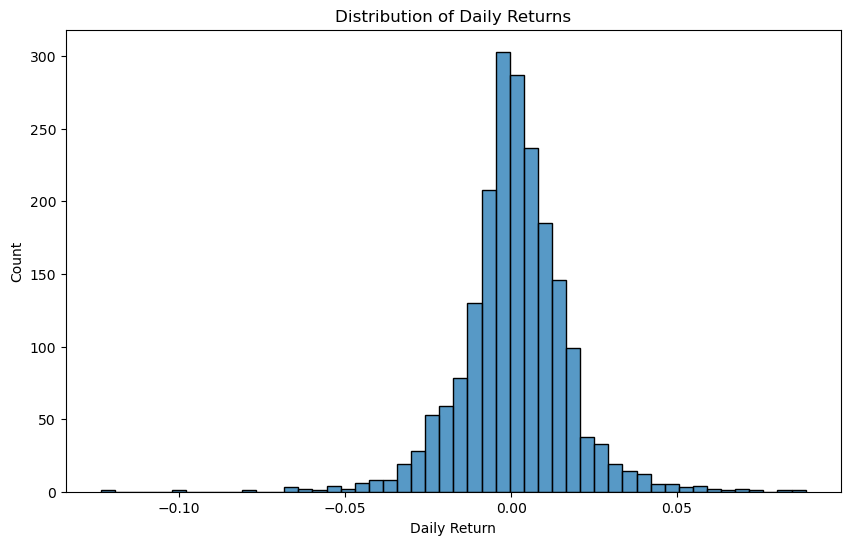

In [21]:
# Distribution Plot

plt.figure(figsize=(10,6))
sns.histplot(df['Daily Return'].dropna(), bins=50)
plt.title('Distribution of Daily Returns')
plt.show()

In [22]:
# Rolling Volatility

df['Volatility'] = df['Daily Return'].rolling(window=30).std()

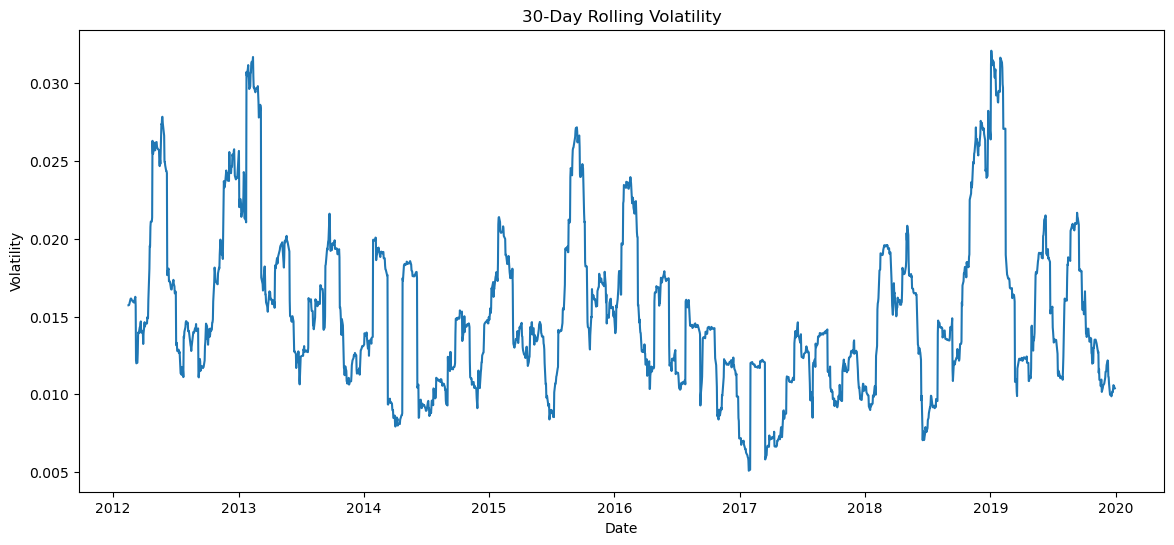

In [23]:
# Plot Volatility

plt.figure(figsize=(14,6))
plt.plot(df['Volatility'])
plt.title('30-Day Rolling Volatility')
plt.xlabel('Date')
plt.ylabel('Volatility')

plt.show()

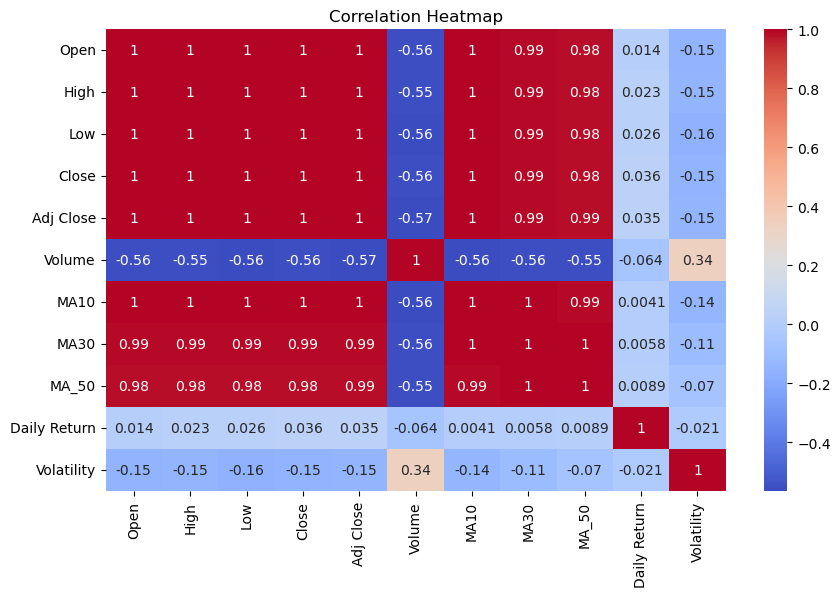

In [24]:
# Correlation Matrix

correlation = df.corr()
plt.figure(figsize=(10,6))
sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [25]:
# Create Lag Features

df['Lag_1'] = df['Adj Close'].shift(1)

df['Lag_7'] = df['Adj Close'].shift(7)

df['Lag_30'] = df['Adj Close'].shift(30)

# Exponential Moving Average

df['EMA_10'] = df['Adj Close'].ewm(span=10, adjust=False).mean()

# # Daily Price Range

# df['Price_Range'] = df['High'] - df['Low']

# # Open Close Difference

# df['Open_Close_Diff'] = df['Open'] - df['Close']

In [26]:
# Date Features

df['Year'] = df.index.year
df['Month'] = df.index.month
df['Day'] = df.index.day
df['Weekday'] = df.index.dayofweek

In [27]:
# Remove Missing Values

df.dropna(inplace=True)

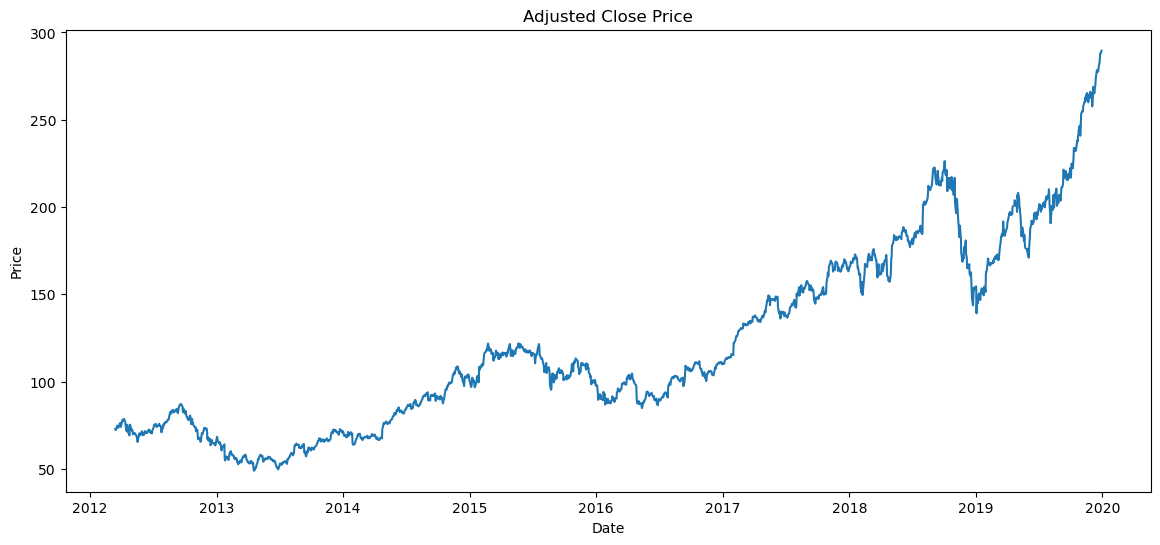

In [28]:
# Plot Adjusted Close Price

plt.figure(figsize=(14,6))
plt.plot(df['Adj Close'])
plt.title('Adjusted Close Price')
plt.xlabel('Date')
plt.ylabel('Price')

plt.show()

In [29]:
# Import ADF Test

from statsmodels.tsa.stattools import adfuller

In [30]:
# Perform ADF Test

result = adfuller(df['Adj Close'])
print("ADF Statistic:", result[0])
print("p-value:", result[1])

df_diff = df['Adj Close'].diff().dropna()

result_diff = adfuller(df_diff)

print('ADF Statistic:', result_diff[0])
print('p-value:', result_diff[1])

ADF Statistic: 1.682928321198486
p-value: 0.9980862181159331
ADF Statistic: -13.321192133401578
p-value: 6.453596190705947e-25


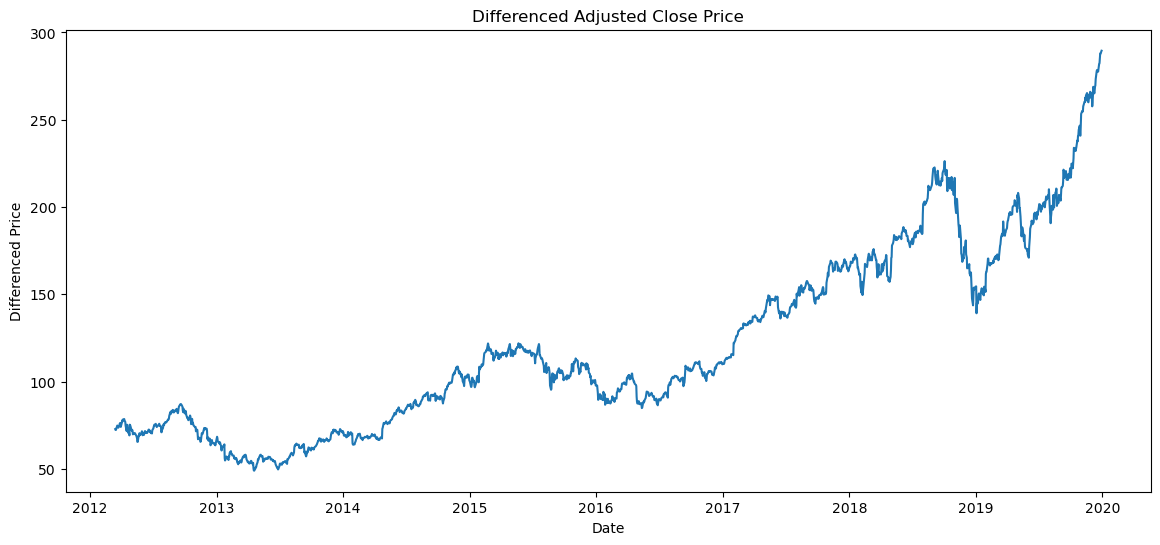

In [31]:
# Plot Differenced Data

plt.figure(figsize=(14,6))
plt.plot(df['Adj Close'])
plt.title('Differenced Adjusted Close Price')
plt.xlabel('Date')
plt.ylabel('Differenced Price')

plt.show()

In [32]:
result_diff = adfuller(df_diff)

print("ADF Statistic:", result_diff[0])
print("p-value:", result_diff[1])

ADF Statistic: -13.321192133401578
p-value: 6.453596190705947e-25


In [33]:
# Select Target Variable
data = df['Adj Close']

In [34]:
# Define Train Size

train_size = int(len(data) * 0.80)

In [35]:
# Split Data

train = data[:train_size]

test = data[train_size:]

In [36]:
# Check Shapes

print("Training Data Size:", train.shape)

print("Testing Data Size:", test.shape)

Training Data Size: (1569,)
Testing Data Size: (393,)


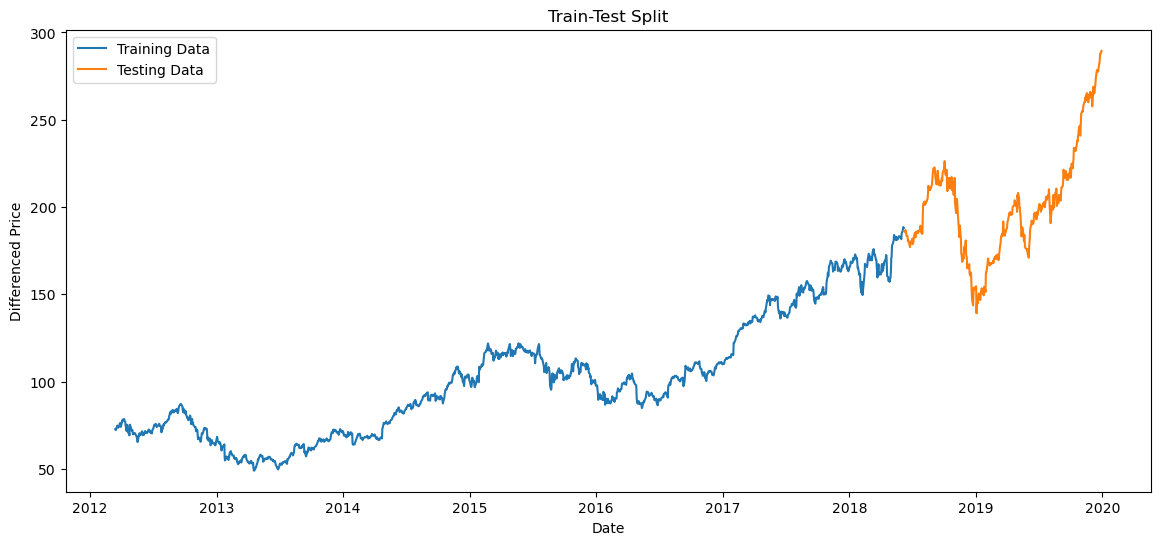

In [37]:
# Plot Train-Test Split

plt.figure(figsize=(14,6))
plt.plot(train, label='Training Data')
plt.plot(test, label='Testing Data')
plt.title('Train-Test Split')
plt.xlabel('Date')
plt.ylabel('Differenced Price')
plt.legend()
plt.show()

In [38]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
import warnings
warnings.filterwarnings("ignore")

best_score = float("inf")
best_order = None

for p in range(0, 6):
    for d in range(0, 3):
        for q in range(0, 6):

            try:

                model = ARIMA(train, order=(p,d,q))
                model_fit = model.fit()

                predictions = model_fit.forecast(
                    steps=len(test)
                )

                rmse = np.sqrt(
                    mean_squared_error(
                        test,
                        predictions
                    )
                )

                if rmse < best_score:

                    best_score = rmse
                    best_order = (p,d,q)

                print(
                    f"ARIMA{(p,d,q)} "
                    f"RMSE={rmse:.4f}"
                )

            except:
                continue

print("\nBest ARIMA Order:", best_order)
print("Best RMSE:", best_score)

ARIMA(0, 0, 0) RMSE=105.0397
ARIMA(0, 0, 1) RMSE=104.9541
ARIMA(0, 0, 2) RMSE=104.8926
ARIMA(0, 0, 3) RMSE=104.8313
ARIMA(0, 0, 4) RMSE=104.8217
ARIMA(0, 0, 5) RMSE=104.7018
ARIMA(0, 1, 0) RMSE=33.3899
ARIMA(0, 1, 1) RMSE=33.4002
ARIMA(0, 1, 2) RMSE=33.4005
ARIMA(0, 1, 3) RMSE=33.3986
ARIMA(0, 1, 4) RMSE=33.3369
ARIMA(0, 1, 5) RMSE=33.3607
ARIMA(0, 2, 0) RMSE=137.5188
ARIMA(0, 2, 1) RMSE=28.4488
ARIMA(0, 2, 2) RMSE=27.7994
ARIMA(0, 2, 3) RMSE=28.1382
ARIMA(0, 2, 4) RMSE=28.1339
ARIMA(0, 2, 5) RMSE=27.5808
ARIMA(1, 0, 0) RMSE=38.5358
ARIMA(1, 0, 1) RMSE=38.8103
ARIMA(1, 0, 2) RMSE=38.4794
ARIMA(1, 0, 3) RMSE=38.5054
ARIMA(1, 0, 4) RMSE=39.1907
ARIMA(1, 0, 5) RMSE=39.0693
ARIMA(1, 1, 0) RMSE=33.3996
ARIMA(1, 1, 1) RMSE=33.3989
ARIMA(1, 1, 2) RMSE=33.4002
ARIMA(1, 1, 3) RMSE=33.4085
ARIMA(1, 1, 4) RMSE=33.3477
ARIMA(1, 1, 5) RMSE=33.2978
ARIMA(1, 2, 0) RMSE=58.2390
ARIMA(1, 2, 1) RMSE=27.7947
ARIMA(1, 2, 2) RMSE=27.8945
ARIMA(1, 2, 3) RMSE=27.9607
ARIMA(1, 2, 4) RMSE=28.1716
ARIMA(1, 2, 5

In [39]:
# pip install pmdarima
from pmdarima import auto_arima

auto_model = auto_arima(
    train,
    seasonal=False,
    trace=True,
    suppress_warnings=True 
)

print(auto_model.summary())




Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=5793.760, Time=1.04 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=5801.909, Time=0.08 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=5800.948, Time=0.20 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=5800.759, Time=0.23 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=5803.486, Time=0.07 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=5803.545, Time=0.56 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=5803.437, Time=0.55 sec
 ARIMA(3,1,2)(0,0,0)[0] intercept   : AIC=5795.194, Time=1.45 sec
 ARIMA(2,1,3)(0,0,0)[0] intercept   : AIC=5795.210, Time=1.51 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=5802.012, Time=0.45 sec
 ARIMA(1,1,3)(0,0,0)[0] intercept   : AIC=5805.107, Time=0.99 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : AIC=5804.765, Time=0.87 sec
 ARIMA(3,1,3)(0,0,0)[0] intercept   : AIC=5796.860, Time=2.46 sec
 ARIMA(2,1,2)(0,0,0)[0]             : AIC=5795.116, Time=0.68 sec

Best model:  ARIMA(2,1,2)(0,0,0)

In [40]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

<Figure size 1200x600 with 0 Axes>

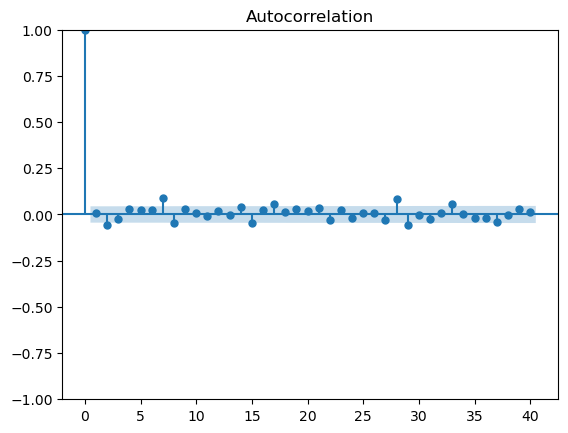

<Figure size 1200x600 with 0 Axes>

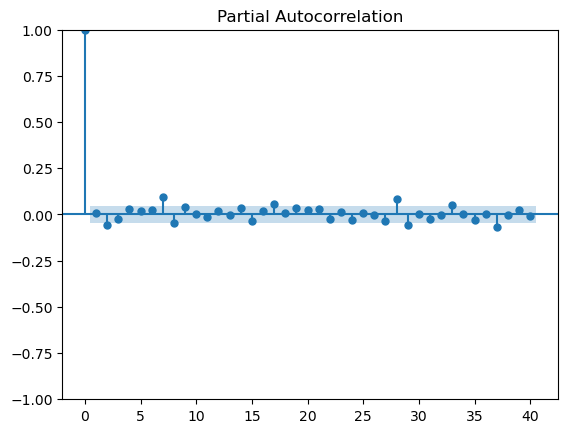

In [41]:
# Plot ACF
plt.figure(figsize=(12,6))
plot_acf(df_diff, lags=40)
plt.show()

# Plot PACF
plt.figure(figsize=(12,6))
plot_pacf(df_diff, lags=40)
plt.show()

In [42]:
from statsmodels.tsa.arima.model import ARIMA

models = [
    (0,1,0),
    (1,1,0),
    (0,1,1),
    (1,1,1),
    (2,1,1),
    (1,1,2),
    (2,1,2),
    (5,2,5),
    (3,1,2)

]

for order in models:
    model = ARIMA(data, order=order)
    result = model.fit()
    print(order, result.aic)

(0, 1, 0) 8386.520709653612
(1, 1, 0) 8388.19650389334
(0, 1, 1) 8388.159647847195
(1, 1, 1) 8387.681516008535
(2, 1, 1) 8386.686860134083
(1, 1, 2) 8387.175595912999
(2, 1, 2) 8378.18076482812
(5, 2, 5) 8380.336845802507
(3, 1, 2) 8380.004729927852


In [43]:
# Build Tuned ARIMA Model
model = ARIMA(train, order=(3,1,2))
model_fit = model.fit()

# Forecast
pred = model_fit.forecast(steps=len(test))
pred = pd.Series(pred.values, index=test.index)

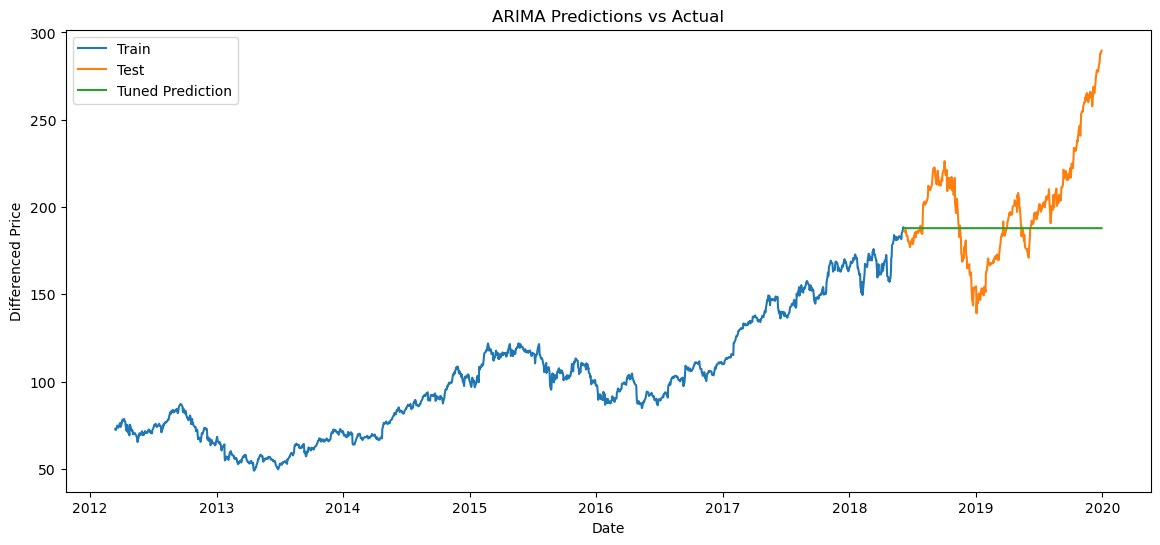

In [44]:
# Plot Actual vs Predicted

plt.figure(figsize=(14,6))
plt.plot(train, label='Train')
plt.plot(test, label='Test')
plt.plot(pred, label='Tuned Prediction')
plt.title('ARIMA Predictions vs Actual')     
plt.xlabel('Date')
plt.ylabel('Differenced Price')
plt.legend()
plt.show()

In [45]:
# Evaluate Tuned ARIMA Model

mae = mean_absolute_error(test, pred)
rmse = np.sqrt(mean_squared_error(test, pred))
mape = mean_absolute_percentage_error(test, pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("MAPE:", mape)

MAE: 24.994191682552792
RMSE: 33.4318788380218
MAPE: 0.11764480591952446


In [46]:
# Build Final ARIMA Model on Full Dataset

final_model = ARIMA(data, order=(3,1,2))
final_model_fit = final_model.fit()

future_forecast = final_model_fit.forecast(steps=30)
future_dates = pd.date_range(start=df.index[-1],periods=31,freq='D')[1:]
future_forecast = pd.Series(future_forecast.values,index=future_dates)
future_forecast

2019-12-31    289.396179
2020-01-01    289.367028
2020-01-02    289.533997
2020-01-03    289.822268
2020-01-04    290.133562
2020-01-05    290.383161
2020-01-06    290.519441
2020-01-07    290.530445
2020-01-08    290.438877
2020-01-09    290.289193
2020-01-10    290.131739
2020-01-11    290.008598
2020-01-12    289.944451
2020-01-13    289.943772
2020-01-14    289.993802
2020-01-15    290.071336
2020-01-16    290.150826
2020-01-17    290.211428
2020-01-18    290.241404
2020-01-19    290.239285
2020-01-20    290.212157
2020-01-21    290.172096
2020-01-22    290.132042
2020-01-23    290.102295
2020-01-24    290.088407
2020-01-25    290.090716
2020-01-26    290.105329
2020-01-27    290.125979
2020-01-28    290.146123
2020-01-29    290.160684
Freq: D, dtype: float64

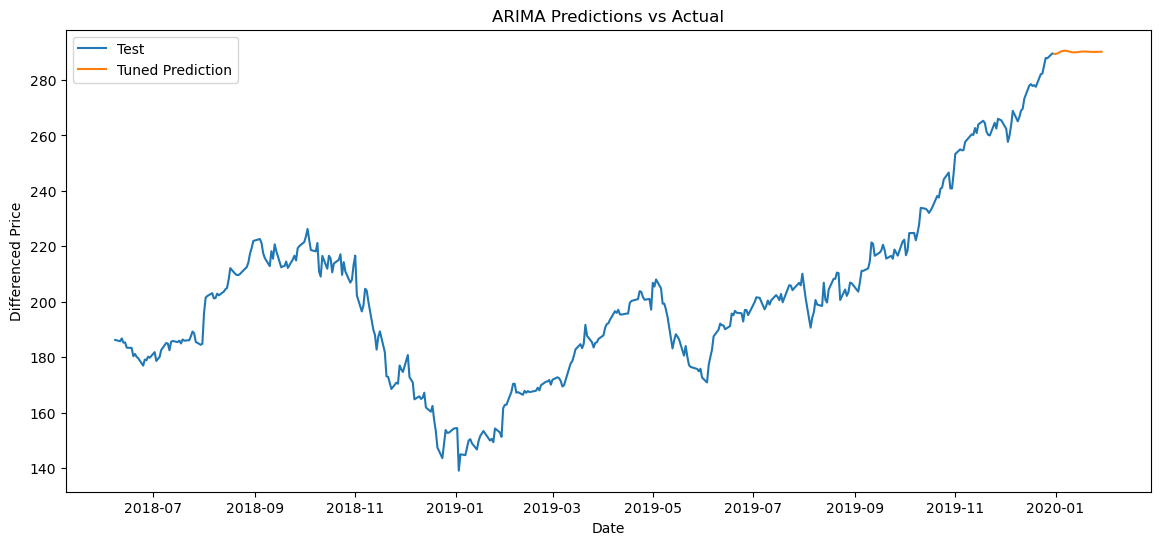

In [47]:
# Plot Actual vs Predicted

plt.figure(figsize=(14,6))

#plt.plot(train, label='Train')
plt.plot(test, label='Test')
plt.plot(future_forecast, label='Tuned Prediction')
plt.title('ARIMA Predictions vs Actual')
plt.xlabel('Date')
plt.ylabel('Differenced Price')
plt.legend()
plt.show()

In [48]:
# Evaluate Tuned ARIMA Model

mae2 = mean_absolute_error(future_dates, future_forecast)
rmse2 = np.sqrt(mean_squared_error(future_dates, future_forecast))
mape2 = mean_absolute_percentage_error(future_dates, future_forecast)

print("MAE:", mae2)
print("RMSE:", rmse2)
print("MAPE:", mape2)

MAE: 1.5790031999999997e+18
RMSE: 1.579003377089536e+18
MAPE: 0.9999999999999999


In [49]:
# # 7-Day Forecast

# forecast_7days = final_model_fit.forecast(steps=7)

# print(forecast_7days)

In [50]:
# sarima
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Build SARIMA Model
sarima_model = SARIMAX(train,order=(3,1,2),seasonal_order=(0,0,0,0))
sarima_fit = sarima_model.fit()

print(sarima_fit.summary())

                               SARIMAX Results                                
Dep. Variable:              Adj Close   No. Observations:                 1569
Model:               SARIMAX(3, 1, 2)   Log Likelihood               -2892.338
Date:                Sun, 05 Jul 2026   AIC                           5796.675
Time:                        10:02:53   BIC                           5828.820
Sample:                             0   HQIC                          5808.624
                               - 1569                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -1.0568      0.081    -13.006      0.000      -1.216      -0.898
ar.L2         -0.7787      0.076    -10.183      0.000      -0.929      -0.629
ar.L3         -0.0194      0.025     -0.775      0.4

In [51]:
sarima_pred = sarima_fit.forecast(steps=len(test))
sarima_pred = pd.Series(sarima_pred.values,index=test.index)
sarima_pred

Date
2018-06-08    187.839976
2018-06-11    187.805992
2018-06-12    187.955274
2018-06-13    187.826548
2018-06-14    187.847002
                 ...    
2019-12-23    187.868684
2019-12-24    187.868684
2019-12-26    187.868684
2019-12-27    187.868684
2019-12-30    187.868684
Length: 393, dtype: float64

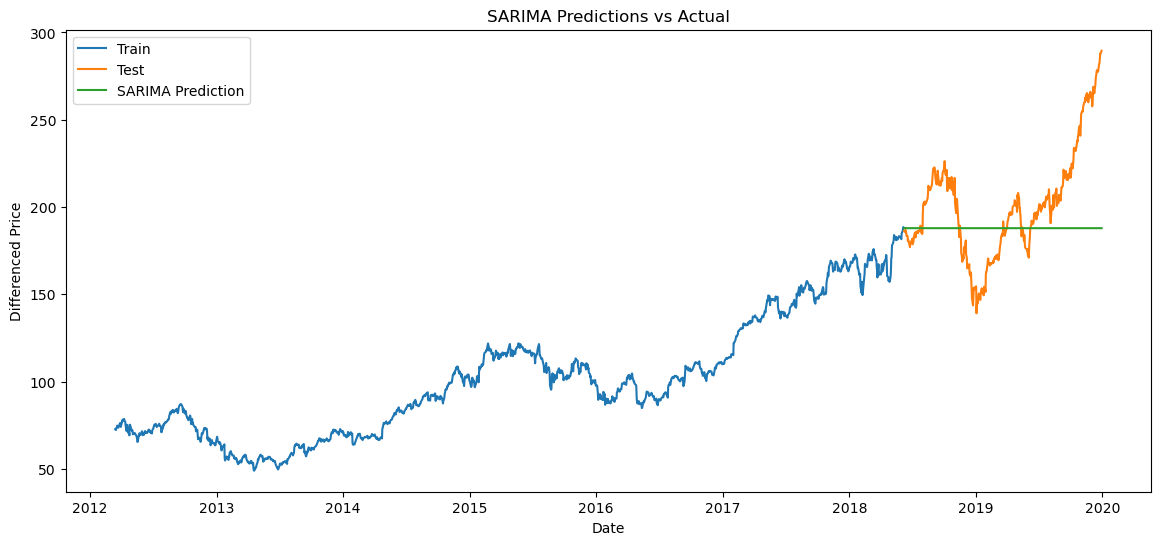

In [52]:
# Plot SARIMA Predictions

plt.figure(figsize=(14,6))
plt.plot(train, label='Train')
plt.plot(test, label='Test')
plt.plot(sarima_pred, label='SARIMA Prediction')
plt.title('SARIMA Predictions vs Actual')
plt.xlabel('Date')
plt.ylabel('Differenced Price')
plt.legend()
plt.show()

In [53]:
# Evaluate SARIMA

sarima_mae = mean_absolute_error(test, sarima_pred)
sarima_rmse = np.sqrt(mean_squared_error(test, sarima_pred))
sarima_mape = mean_absolute_percentage_error( test,sarima_pred)

print("MAE:", sarima_mae)
print("RMSE:", sarima_rmse)
print("MAPE:", sarima_mape)

MAE: 24.994191682552792
RMSE: 33.4318788380218
MAPE: 0.11764480591952446


In [54]:
# Train on Full Data

final_sarima = SARIMAX( data,order=(3,1,2),seasonal_order=(0,0,0,0))
final_sarima_fit = final_sarima.fit()

In [55]:
future_sarima = final_sarima_fit.forecast(steps=30)
future_dates = pd.date_range(start=df.index[-1],periods=31,freq='D')[1:]
future_sarima = pd.Series(future_sarima.values,index=future_dates)
future_sarima

2019-12-31    289.396179
2020-01-01    289.367028
2020-01-02    289.533997
2020-01-03    289.822268
2020-01-04    290.133562
2020-01-05    290.383161
2020-01-06    290.519441
2020-01-07    290.530445
2020-01-08    290.438877
2020-01-09    290.289193
2020-01-10    290.131739
2020-01-11    290.008598
2020-01-12    289.944451
2020-01-13    289.943772
2020-01-14    289.993802
2020-01-15    290.071336
2020-01-16    290.150826
2020-01-17    290.211428
2020-01-18    290.241404
2020-01-19    290.239285
2020-01-20    290.212157
2020-01-21    290.172096
2020-01-22    290.132042
2020-01-23    290.102295
2020-01-24    290.088407
2020-01-25    290.090716
2020-01-26    290.105329
2020-01-27    290.125979
2020-01-28    290.146123
2020-01-29    290.160684
Freq: D, dtype: float64

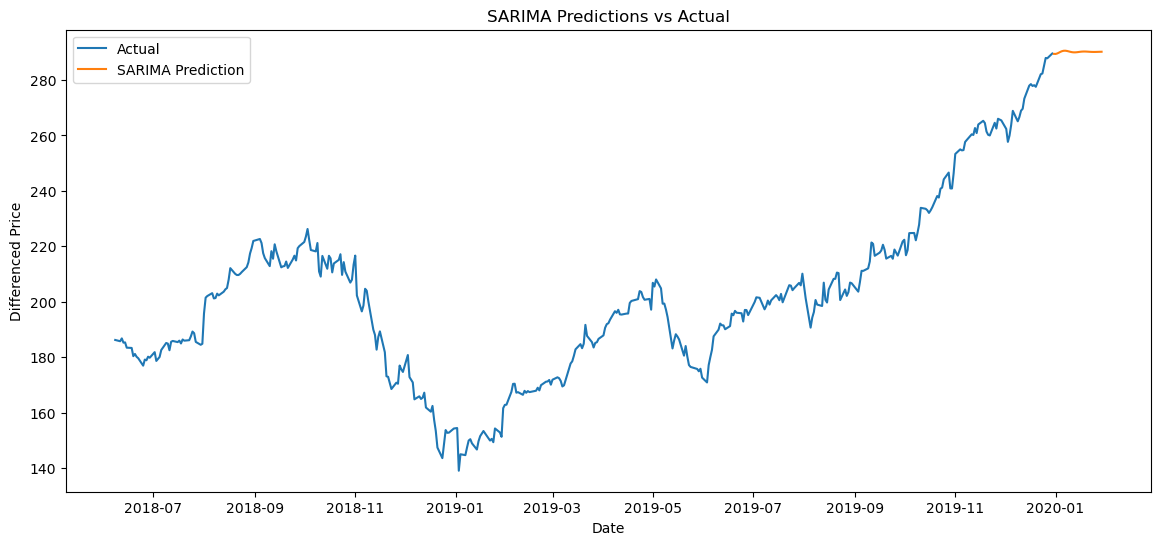

In [56]:
# Plot SARIMA Predictions

plt.figure(figsize=(14,6))
plt.plot(test, label='Actual')
plt.plot(future_sarima, label='SARIMA Prediction')
plt.title('SARIMA Predictions vs Actual')
plt.xlabel('Date')
plt.ylabel('Differenced Price')
plt.legend()
plt.show()

In [57]:
#pip install xgboost

(1568, 12)
(393, 12)
(1568,)
(393,)
[186.55405 186.94867 186.062   186.37941 186.42232 185.94017 186.1649
 182.30788 182.55444 179.61618]


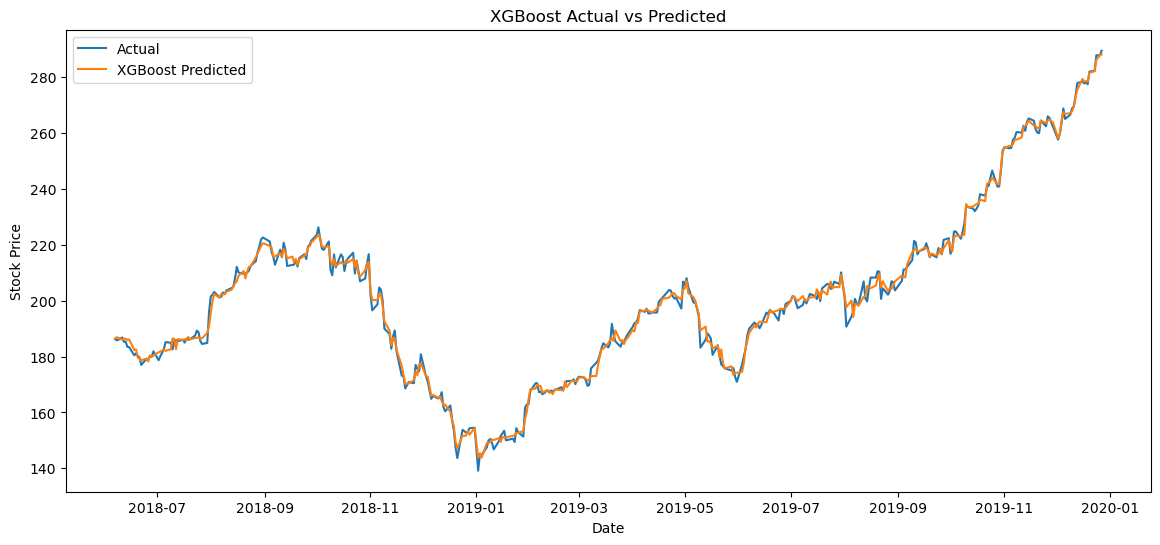

MAE : 1.4936529972864983
RMSE: 1.9321177572299333
MAPE: 0.007681492170361495


<Figure size 1000x800 with 0 Axes>

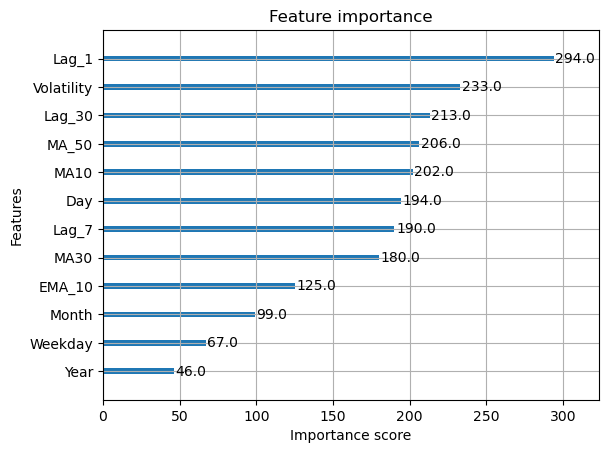

2019-12-30    286.688812
2019-12-31    286.778992
2020-01-01    266.474091
2020-01-02    261.205872
2020-01-03    262.495819
2020-01-06    263.796967
2020-01-07    263.937744
2020-01-08    262.974121
2020-01-09    263.191010
2020-01-10    263.373657
2020-01-13    264.882721
2020-01-14    256.351013
2020-01-15    254.047028
2020-01-16    254.263977
2020-01-17    254.500473
2020-01-20    255.544937
2020-01-21    256.278107
2020-01-22    255.736069
2020-01-23    257.644775
2020-01-24    259.082001
2020-01-27    260.395264
2020-01-28    260.028168
2020-01-29    258.516907
2020-01-30    260.313080
2020-01-31    261.188171
2020-02-03    261.536591
2020-02-04    262.346771
2020-02-05    258.345825
2020-02-06    256.434174
2020-02-07    260.128876
Freq: B, dtype: float32


In [58]:
# Features


# y = df['Adj Close']
df['Target'] = df['Adj Close'].shift(-1)

df = df.dropna().copy()


X = df[
    [
        'MA10',
        'MA30',
        'MA_50',
        'Volatility',
        'Lag_1',
        'Lag_7',
        'Lag_30',
        'EMA_10',
        'Year',
        'Month',
        'Day',
        'Weekday'
    ]
]

				

# Target

y = df['Target']

# df['Return'] = df['Adj Close'].pct_change()

# df = df.dropna().copy()

# X = df[
#     [
#         'MA10',
#         'MA30',
#         'MA_50',
#         'Volatility',
#         'Lag_1',
#         'Lag_7',
#         'Lag_30',
#         'EMA_10'
#     ]
# ]

# y = df['Return']



split = int(len(df) * 0.80)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]


print(X_train.shape)
print(X_test.shape)

print(y_train.shape)
print(y_test.shape)


from xgboost import XGBRegressor


xgb_model = XGBRegressor(n_estimators=300,learning_rate=0.1,max_depth=3,random_state=42)
# xgb_model.fit(X_train, y_train)


# Train for evaluation
xgb_model.fit(X_train, y_train)

# Evaluate
xgb_pred = xgb_model.predict(X_test)

# Retrain using all historical data
xgb_model.fit(X, y)


xgb_pred = xgb_model.predict(X_test)


print(xgb_pred[:10])


plt.figure(figsize=(14,6))
#plt.plot(y_train.index, y_train, label='Actual')
plt.plot(y_test.index, y_test, label='Actual')
plt.plot(y_test.index, xgb_pred, label='XGBoost Predicted')
plt.title('XGBoost Actual vs Predicted')
plt.xlabel('Date')
plt.ylabel('Stock Price')
plt.legend()
plt.show()


mae = mean_absolute_error(y_test, xgb_pred)
rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))
mape = mean_absolute_percentage_error(y_test, xgb_pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("MAPE:", mape)


from xgboost import plot_importance
plt.figure(figsize=(10,8))
plot_importance(xgb_model,max_num_features=15)
plt.show()




future_days = 30

history = df['Adj Close'].tolist()

future_predictions = []

for _ in range(future_days):

    lag_1 = history[-1]
    lag_7 = history[-7]
    lag_30 = history[-30]

    ma10 = np.mean(history[-10:])
    ma30 = np.mean(history[-30:])
    ma50 = np.mean(history[-50:])

    # volatility = np.std(history[-10:])
    returns = pd.Series(history).pct_change()

    volatility = returns[-30:].std()

    ema10 = pd.Series(history[-10:]).ewm(span=10).mean().iloc[-1]

    # future_features = pd.DataFrame({
    #     'MA10': [ma10],
    #     'MA30': [ma30],
    #     'MA_50': [ma50],
    #     'Volatility': [volatility],
    #     'Lag_1': [lag_1],
    #     'Lag_7': [lag_7],
    #     'Lag_30': [lag_30],
    #     'EMA_10': [ema10]
    # })

    # Create the next business date
    future_date = df.index[-1] + pd.offsets.BDay(len(future_predictions) + 1)

    future_features = pd.DataFrame({
    'MA10': [ma10],
    'MA30': [ma30],
    'MA_50': [ma50],
    'Volatility': [volatility],
    'Lag_1': [lag_1],
    'Lag_7': [lag_7],
    'Lag_30': [lag_30],
    'EMA_10': [ema10],
    'Year': [future_date.year],
    'Month': [future_date.month],
    'Day': [future_date.day],
    'Weekday': [future_date.weekday()]
})
    

    next_price = xgb_model.predict(future_features)[0]

    future_predictions.append(next_price)

    history.append(next_price)
    


future_dates = pd.date_range(
    start=df.index[-1] + pd.Timedelta(days=1),
    periods=30,
    freq='B'
)

future_series = pd.Series(
    future_predictions,
    index=future_dates
)

print(future_series)




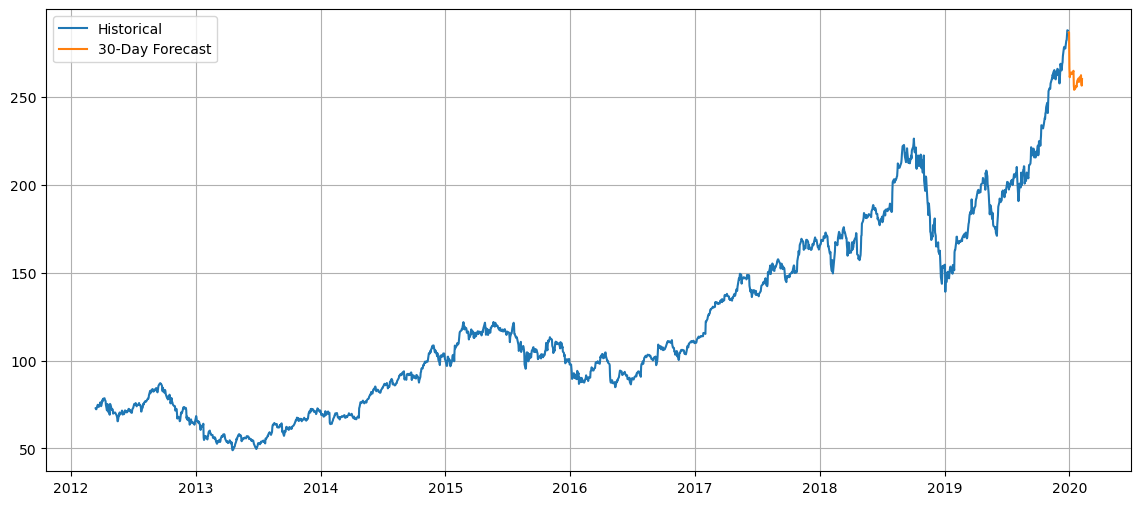

In [59]:
plt.figure(figsize=(14,6))

plt.plot(df.index, df['Adj Close'], label='Historical')

plt.plot(
    future_series.index,
    future_series.values,
    label='30-Day Forecast'
)

plt.legend()
plt.grid(True)
plt.show()



In [66]:
import pandas as pd
import numpy as np
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

# Evaluation Function
def evaluate_model(y_true, y_pred):

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = mean_absolute_percentage_error(y_true, y_pred)

    return mae, rmse, mape



arima_mae, arima_rmse, arima_mape = evaluate_model(y_test, pred)
sarima_mae, sarima_rmse, sarima_mape = evaluate_model(y_test, sarima_pred)
xgb_mae, xgb_rmse, xgb_mape = evaluate_model(y_test, xgb_pred)


# ===========================
# Comparison Table
# ===========================

comparison = pd.DataFrame({

    "Model": ["ARIMA", "SARIMA", "XGBoost"],

    "MAE": [
        arima_mae,
        sarima_mae,
        xgb_mae
    ],

    "RMSE": [
        arima_rmse,
        sarima_rmse,
        xgb_rmse
    ],

    "MAPE": [
        arima_mape,
        sarima_mape,
        xgb_mape
    ]

})

print(comparison)

     Model        MAE       RMSE      MAPE
0    ARIMA  24.994192  33.431879  0.117645
1   SARIMA  24.994192  33.431879  0.117645
2  XGBoost   1.493653   1.932118  0.007681


In [67]:
best_model = comparison.loc[comparison["RMSE"].idxmin()]

print("\nBest Model")
print(best_model)


Best Model
Model     XGBoost
MAE      1.493653
RMSE     1.932118
MAPE     0.007681
Name: 2, dtype: object


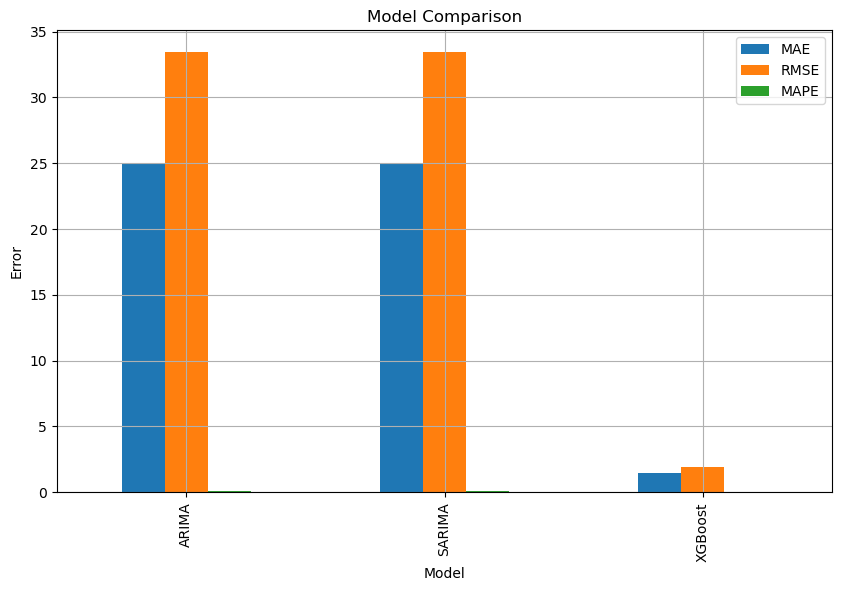

In [68]:
import matplotlib.pyplot as plt

comparison.set_index("Model").plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Model Comparison")
plt.ylabel("Error")
plt.grid(True)
plt.show()

In [87]:
import joblib

if best_model_name == "XGBoost":

    joblib.dump(xgb_model, "xgboost_stock_model.pkl")

elif best_model_name == "ARIMA":

    joblib.dump(final_model_fit, "arima_model.pkl")

elif best_model_name == "SARIMA":

    joblib.dump(final_sarima_fit, "sarima_model.pkl")

print("Model Saved Successfully")

Model Saved Successfully


In [88]:
model = joblib.load("xgboost_stock_model.pkl")

print(type(model))

<class 'xgboost.sklearn.XGBRegressor'>


In [70]:
# pip install joblib

In [79]:
# pip install streamlit

In [61]:
# # Secound model 

# from xgboost import XGBRegressor
# from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
# from sklearn.metrics import (
#     mean_absolute_error,
#     mean_squared_error,
#     mean_absolute_percentage_error
# )



# tscv = TimeSeriesSplit(n_splits=5)


# xgb = XGBRegressor(
#     objective='reg:squarederror',
#     random_state=42
# )



# param_grid = {
#     'n_estimators': [100, 300, 500, 700],
#     'max_depth': [3, 5, 7],
#     'learning_rate': [0.01, 0.05, 0.1],
#     'subsample': [0.7, 0.8, 0.9],
#     'colsample_bytree': [0.7, 0.8, 0.9]
# }




# from sklearn.model_selection import RandomizedSearchCV

# random_search = RandomizedSearchCV(
#     estimator=xgb,
#     param_distributions=param_grid,
#     n_iter=50,
#     cv=tscv,
#     scoring='neg_mean_squared_error',
#     n_jobs=-1,
#     random_state=42,
#     verbose=2
# )

# random_search.fit(X_train, y_train)

# print("Best Parameters:")
# print(random_search.best_params_)

# print("Best Score:")
# print(random_search.best_score_)


# best_xgb = random_search.best_estimator_


# best_xgb.fit(X, y)


# best_pred = best_xgb.predict(X_test)


# mae = mean_absolute_error(y_test, best_pred)

# rmse = np.sqrt(mean_squared_error(y_test, best_pred))

# mape = mean_absolute_percentage_error(y_test,best_pred)

# print("MAE :", mae)
# print("RMSE:", rmse)
# print("MAPE:", mape)


# plt.figure(figsize=(14,6))
# plt.plot(y_test.index,y_test,label='Actual')
# plt.plot(y_test.index,best_pred,label='Tuned XGBoost')
# plt.title('Tuned XGBoost Actual vs Predicted')
# plt.xlabel('Date')
# plt.ylabel('Stock Price')
# plt.legend()
# plt.show()

In [62]:
# from xgboost import plot_importance

# plt.figure(figsize=(10,8))
# plot_importance(best_xgb,max_num_features=15)
# plt.show()

# best_xgb.fit(X, y)

# current_row = X.iloc[-1].copy()

# future_predictions = []

# for i in range(30):

#     pred = best_xgb.predict(
#         current_row.values.reshape(1,-1)
#     )[0]

#     future_predictions.append(pred)

#     current_row['Lag_30'] = current_row['Lag_7']
#     current_row['Lag_7'] = current_row['Lag_1']
#     current_row['Lag_1'] = pred


# future_dates = pd.date_range(
#     start=df.index[-1] + pd.Timedelta(days=1),
#     periods=30,
#     freq='D'
# )

# future_forecast = pd.Series(
#     future_predictions,
#     index=future_dates
# )


# plt.figure(figsize=(14,6))

# plt.plot(
#     df['Adj Close'].tail(200),
#     label='Historical'
# )

# plt.plot(
#     future_forecast,
#     label='30-Day Forecast'
# )

# plt.title('XGBoost Future Forecast')

# plt.xlabel('Date')
# plt.ylabel('Stock Price')

# plt.legend()
# plt.show()